CSV TO DATAFRAME

In [3]:
import pandas as pd

df = pd.read_csv("data/priceRelatedFeatures.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

           category                                              title  \
0  wireless earbuds  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...   
1  wireless earbuds  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...   
2  wireless earbuds  XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 ...   
3  wireless earbuds  Wireless Earbuds Bluetooth Headphones, 54H Pla...   
4  wireless earbuds  HAOYUYAN Wireless Earbuds, Sports Bluetooth He...   

      brand  rating ratingCount  \
0    Fhumsh     4.8       (350)   
1    Fhumsh     4.8       (350)   
2  XIAOWTEK     4.9       (673)   
3    TRAUSI     4.8       (220)   
4  HAOYUYAN     4.9       (234)   

                                         description  \
0  About this itemSmart LED Display & 50H Sport H...   
1  About this itemErgonomic Wireless Earbuds for ...   
2  About this itemLED Power Display and 50H Playb...   
3  About this item【Instant Pairing & Seamless Con...   
4  About this item【Sports Comfort & IPX7 Waterpro...   

       

Data Preprocessing

In [5]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)

category         0
title            0
brand          161
rating           3
ratingCount      3
description    144
price          124
dtype: int64
category        0.000000
title           0.000000
brand          19.350962
rating          0.360577
ratingCount     0.360577
description    17.307692
price          14.903846
dtype: float64


In [6]:
df = df.dropna(subset=["price"])

print(df.isnull().sum())

category         0
title            0
brand          147
rating           2
ratingCount      2
description    132
price            0
dtype: int64


In [7]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 47


In [8]:
print(
    "Duplicate products:",
    df.duplicated(
        subset=["title", "brand"]
    ).sum()
)

Duplicate products: 83


In [9]:
duplicates = df[
    df.duplicated(
        subset=["title", "brand"],
        keep=False
    )
].sort_values(["title", "brand"])

print(duplicates[
    ["title", "brand", "category", "price", "ratingCount"]
].head(30))

                                                 title              brand  \
587  "Moleskine Classic Notebook, Soft Cover, Large...                NaN   
591  "Moleskine Classic Notebook, Soft Cover, Large...                NaN   
780  3 in 1 Mag-Safe Wireless Charger Stand for iPh...             Ouotoo   
781  3 in 1 Mag-Safe Wireless Charger Stand for iPh...             Ouotoo   
826  40/41/42" Acoustic Guitar Bag,Oxford Fabric wi...                NaN   
827  40/41/42" Acoustic Guitar Bag,Oxford Fabric wi...                NaN   
593  A5 Lined Notebook 5.9"x8.4", Hardcover Leather...            vfaejll   
598  A5 Lined Notebook 5.9"x8.4", Hardcover Leather...            vfaejll   
474  AOC 27 Inch Computer Monitor FHD 120Hz Fast IP...                AOC   
475  AOC 27 Inch Computer Monitor FHD 120Hz Fast IP...                AOC   
473  AOC 27" Gaming Monitor QHD 260Hz Overclocked I...                AOC   
478  AOC 27" Gaming Monitor QHD 260Hz Overclocked I...                AOC   

In [10]:
df.drop_duplicates(inplace=True)

In [11]:


print("Shape after removing exact duplicates:", df.shape)
print("Remaining exact duplicates:", df.duplicated().sum())

Shape after removing exact duplicates: (661, 7)
Remaining exact duplicates: 0


In [12]:
df["price"] = (
    df["price"]
    .str.extract(r"\$([\d,]+(?:\.\d+)?)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [13]:
print(df["price"].head(20))
print(df["price"].dtype)

0      19.97
1      19.97
2      19.99
3      20.99
4      23.98
5      36.52
7      19.99
8      13.99
9      16.99
10     47.99
11      9.99
12     26.55
14    249.99
15     16.99
16     34.98
17    179.95
18     14.97
19     48.99
20     16.99
21     19.99
Name: price, dtype: float64
float64


In [14]:
print("Missing prices:", df["price"].isna().sum())

Missing prices: 0


In [15]:
print(df["price"].describe())

count     661.000000
mean       71.598185
std       110.600799
min         2.790000
25%        16.990000
50%        29.990000
75%        79.990000
max      1145.000000
Name: price, dtype: float64


In [16]:
print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())
print("Median price:", df["price"].median())

Minimum price: 2.79
Maximum price: 1145.0
Median price: 29.99


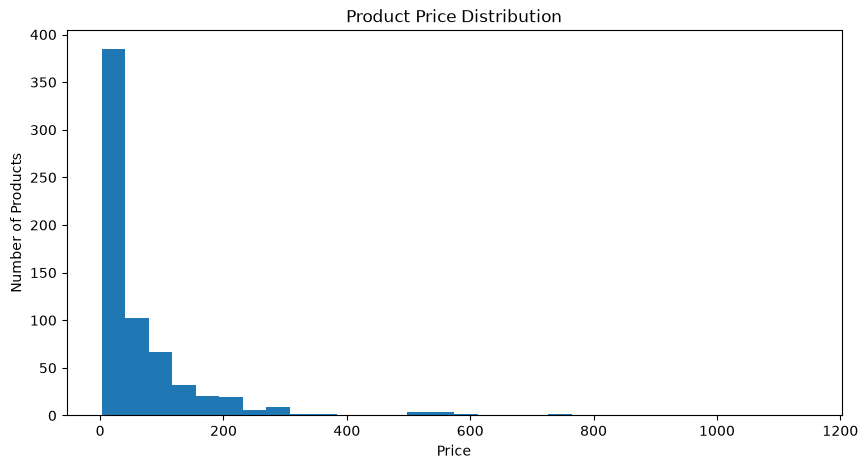

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["price"], bins=30)

plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.title("Product Price Distribution")

plt.show()

In [18]:
print(df.columns.tolist())

['category', 'title', 'brand', 'rating', 'ratingCount', 'description', 'price']


In [19]:
print("Duplicate titles:", df.duplicated(subset=["title"]).sum())

Duplicate titles: 46


In [20]:
print(df["price"].describe())

count     661.000000
mean       71.598185
std       110.600799
min         2.790000
25%        16.990000
50%        29.990000
75%        79.990000
max      1145.000000
Name: price, dtype: float64


In [21]:
print(df["category"].value_counts())

category
desk lamp LED              47
sneakers                   44
sunglasses                 43
notebook journal           42
t-shirt                    40
candle                     39
kitchen knife set          38
water bottle               37
yamaha accoustic guitar    35
electric toothbrush        33
gaming chair               30
coffee maker               29
mechanical keyboard        16
smartwatch                 16
webcam HD                  16
instant pot                16
gaming mouse               15
phone case                 15
wireless earbuds           14
USB-C hub                  13
backpack                   13
phone stand                13
monitor 27 inch            12
portable charger           11
bluetooth speaker          11
DSLR camera                10
budget laptop               9
air purifier                4
Name: count, dtype: int64


In [22]:
category_price_stats = df.groupby("category")["price"].agg(
    ["count", "min", "median", "max"]
).sort_values("count", ascending=False)

print(category_price_stats)

                         count    min   median      max
category                                               
desk lamp LED               47   9.99   25.490    79.99
sneakers                    44  19.90   52.875    90.00
sunglasses                  43   6.99   15.990   229.00
notebook journal            42   2.79   10.990    36.99
t-shirt                     40   5.99   12.670    36.99
candle                      39   9.99   19.990   119.98
kitchen knife set           38  19.98   79.980  1145.00
water bottle                37   8.99   24.000    50.00
yamaha accoustic guitar     35   5.99   72.990   599.99
electric toothbrush         33   7.99   48.590   379.96
gaming chair                30  25.99  132.480   408.84
coffee maker                29  21.99   74.950   555.95
instant pot                 16  67.94  109.990   219.99
smartwatch                  16  13.99   71.990   799.99
webcam HD                   16  18.99   58.180   199.59
mechanical keyboard         16  15.99   61.490  